# Task 3: Clustering Analysis

**Index:**
1. Load Engineered Data
2. K-Means Clustering
   2.1 K-Means K-Value Exploration
   2.2 K-Means K=4 Detailed Analysis
3. Hierarchical Clustering
   3.1 Hierarchical Linkage Comparison
   3.2 Hierarchical K-Value Exploration
4. Gaussian Mixture Models (GMM)
   4.1 GMM K-Value and Covariance Exploration
5. Multi-Algorithm Comparison
6. Best Algorithm Analysis

In [1]:
import sys
import os

# Add project root to path so src can be imported
project_root = os.path.abspath(os.path.join(os.getcwd(), ".."))
if project_root not in sys.path:
    sys.path.insert(0, project_root)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Import clustering utilities
from src.clustering import (
    evaluate_clustering,
    plot_cluster_scatter,
    plot_algorithm_comparison,
    compare_clusters_to_classes,
)

# Set plotting style
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 11

# Ensure plots directory exists
os.makedirs(os.path.join(project_root, "data", "plots"), exist_ok=True)

## 1. Load Engineered Data

In [2]:
# Load engineered train/val/test data and concatenate to full dataset
features_train = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_train.csv'))
targets_train = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_train.csv')).iloc[:, 0]

features_val = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_val.csv'))
targets_val = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_val.csv')).iloc[:, 0]

features_test = pd.read_csv(os.path.join(project_root, 'data', 'features_engineered_test.csv'))
targets_test = pd.read_csv(os.path.join(project_root, 'data', 'targets_engineered_test.csv')).iloc[:, 0]

# Concatenate to full dataset
X_raw = pd.concat([features_train, features_val, features_test], axis=0, ignore_index=True)
y_raw = pd.concat([targets_train, targets_val, targets_test], axis=0, ignore_index=True)

### Different: filter out ordinal features (so that no target encode info is leaked to clustering)
from src.preprocessing import get_feature_types
feature_types = get_feature_types(X_raw)
print("Feature types:", feature_types)
# All features except ordinal
non_ordinal_features = X_raw.columns.difference(feature_types["ordinal"]).tolist()
X = X_raw[non_ordinal_features]
y = y_raw

print(f"Features shape: {X.shape}")
print(f"Target distribution:")
print(y.value_counts().sort_index().to_string())

print("Feature list:")
for feature in X.columns:
	print(f"  {feature}")

Feature types: {'nominal': ['Marital Status', 'Application mode', 'Course', 'Nacionality', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation"], 'binary': ['Tuition fees up to date', 'Scholarship holder'], 'count': ['Age at enrollment', 'Application order', 'Curricular units 1st sem (approved)', 'Curricular units 1st sem (enrolled)', 'Curricular units 1st sem (evaluations)', 'Curricular units 2nd sem (approved)', 'Curricular units 2nd sem (enrolled)', 'Curricular units 2nd sem (evaluations)', 'approval_rate_1st', 'approval_rate_2nd', 'economic_condition', 'evaluation_intensity_1st', 'evaluation_intensity_2nd', 'grade_improvement', 'grade_per_evaluation_1st', 'grade_per_evaluation_2nd', 'no_financial_stress', 'overall_approval_rate', 'parent_avg_qualification', 'parent_max_qualification', 'parent_qualification_gap', 'total_approved', 'total_enrolled'], 'ordinal': ['Age at enrollment', 'Application order', 'Curricular units 1st sem (approved)'

In [3]:
# Compute 2D t-SNE for visualization 
from src.visualization import (
    compute_tsne,
    plot_tsne_2d,
    plot_tsne_2d_multi
)

perp = 30
tsne_embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
print(tsne_embedding.shape)

t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
(4424, 2)


## 2.0 t-SNE scatter colored by true class

t-SNE done: perplexity=30, n_components=2, shape=(4424, 2)
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_tsne_perp_30.png


<Axes: title={'center': 't-SNE Projection (p=30)'}, xlabel='Dimension 1', ylabel='Dimension 2'>

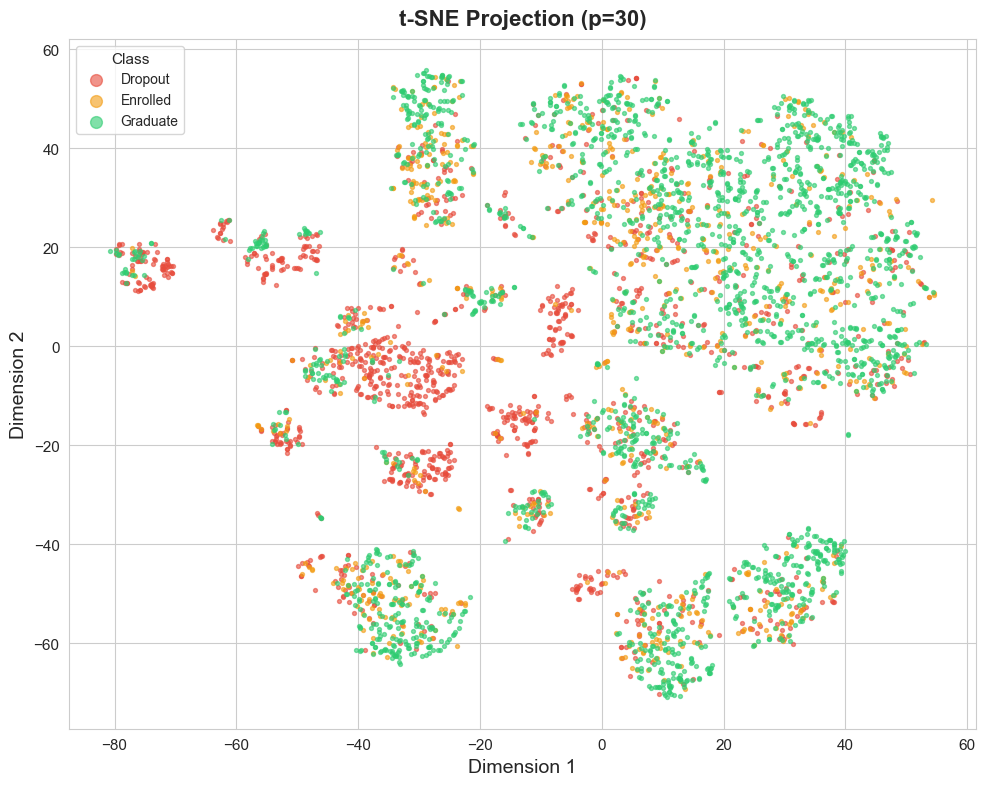

In [4]:
embedding = compute_tsne(X.values, perplexity=perp, n_components=2)
plot_tsne_2d(
	embedding, 
	labels=y, 
	save_path=os.path.join(project_root, "data", "plots", f"03a_tsne_perp_{perp}.png")
)

Three clustering algorithms with distinct assumptions are selected:

1. **K-Means**
2. **Agglomerative Hierarchical**
3. **GMM**

## 2.1 K-Means K-Value Exploration

We explore larger K values (K=3,4,5,6) to determine whether splitting classes into more clusters improves alignment with true labels. While K=3 matches the number of target classes, the target-encoded features may benefit from additional cluster granularity.

In [5]:
# K-Means K-Value Exploration
from sklearn.cluster import KMeans

print("K-Means K-Value Exploration:")
print(f"{'K':>3} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

kmeans_results = {}
for k in range(3,20):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    kmeans_results[k] = {"labels": labels, "metrics": metrics}
    print(f"{k:>3} | {metrics.get('adjusted_rand_index', 0):>8.4f} | {metrics.get('normalized_mutual_info', 0):>8.4f} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>10.2f} | {metrics.get('davies_bouldin', 0):>10.4f}")

K-Means K-Value Exploration:
  K |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
  3 |   0.1709 |   0.1739 |     0.2224 |     642.16 |     1.7481
  4 |   0.1572 |   0.1379 |     0.2282 |     592.06 |     1.6740
  5 |   0.1046 |   0.1058 |     0.1513 |     568.58 |     1.8103
  6 |   0.0753 |   0.0897 |     0.1342 |     529.86 |     1.9493
  7 |   0.0738 |   0.0884 |     0.1322 |     515.14 |     1.7670
  8 |   0.0558 |   0.0776 |     0.1327 |     489.63 |     1.7194
  9 |   0.0539 |   0.0777 |     0.1372 |     469.86 |     1.7026
 10 |   0.0488 |   0.0741 |     0.1389 |     452.03 |     1.6555
 11 |   0.0506 |   0.0914 |     0.1220 |     419.19 |     1.9099
 12 |   0.0440 |   0.0803 |     0.1343 |     414.41 |     1.7473
 13 |   0.0439 |   0.0815 |     0.1254 |     395.23 |     1.7795
 14 |   0.0374 |   0.0783 |     0.1245 |     377.06 |     1.8310
 15 |   0.0380 |   0.0801 |     0.1286 |     365.90 |     1.

Key Finding: K=3 achieves the best ARI (0.1709), suggesting that the target-encoded features benefit from finer cluster granularity.

## 2.2 K-Means Detailed Analysis

K-Means (K=4) Metrics:
  silhouette: 0.2282
  silhouette_std: 0.0901
  calinski_harabasz: 592.0562
  davies_bouldin: 1.6740
  noise_ratio: 0.0000
  adjusted_rand_index: 0.1572
  normalized_mutual_info: 0.1379

K-Means Cluster Size Distribution:
 Cluster  Count  Percentage
       0    427         9.7
       1   3091        69.9
       2    709        16.0
       3    197         4.5

K-Means Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           180   68   179
1           545  648  1898
2           558   75    76
3           138    3    56

Dominant Class per Cluster:
  Cluster 0: Dropout (42.2%)
  Cluster 1: Graduate (61.4%)
  Cluster 2: Dropout (78.7%)
  Cluster 3: Dropout (70.1%)
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_kmeans_clusters_tsne.png


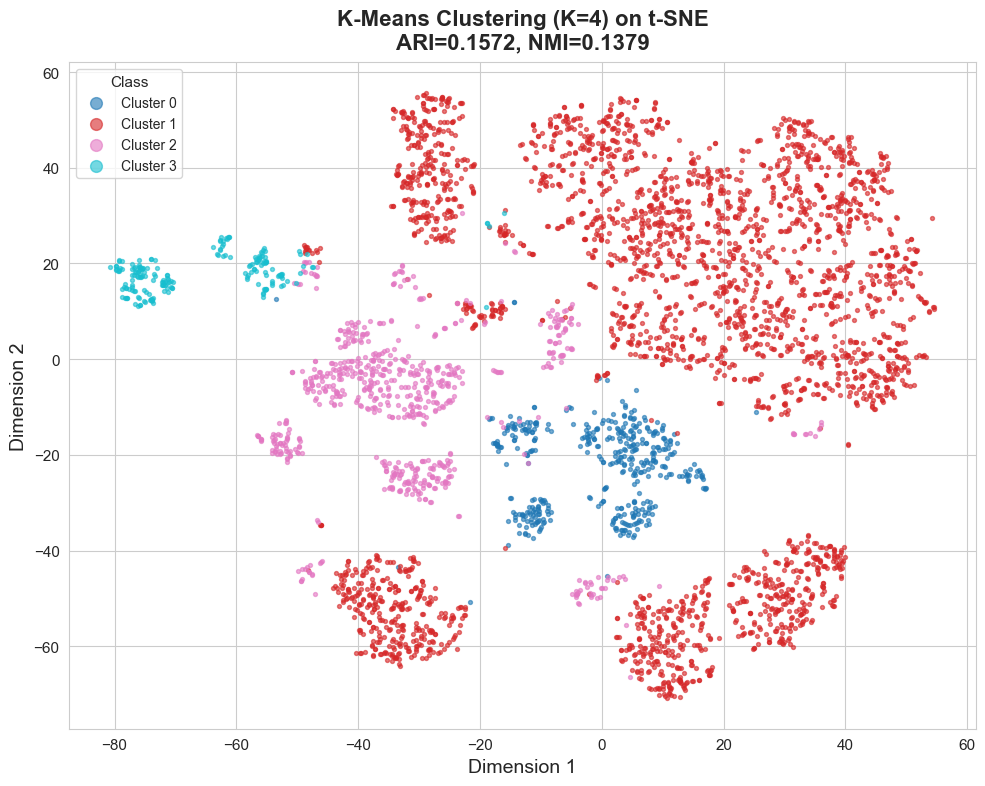

In [6]:
# K-Means Detailed Analysis (t-SNE visualization)

best_k = 4
kmeans_labels = kmeans_results[best_k]["labels"]
kmeans_metrics = kmeans_results[best_k]["metrics"]

# Update optimal_k for later comparison section
optimal_k = best_k

print(f"K-Means (K={best_k}) Metrics:")
for name, value in kmeans_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# K-Means K=4 cluster size distribution
kmeans4_cluster_sizes = pd.Series(kmeans_labels).value_counts().sort_index()
kmeans4_size_df = pd.DataFrame({
    "Cluster": kmeans4_cluster_sizes.index,
    "Count": kmeans4_cluster_sizes.values,
    "Percentage": (kmeans4_cluster_sizes.values / len(kmeans_labels) * 100).round(1)
})
print("\nK-Means Cluster Size Distribution:")
print(kmeans4_size_df.to_string(index=False))

# K-Means K=4 cross-tabulation
class_names = {0: "Dropout", 1: "Enrolled", 2: "Graduate"}
kmeans4_crosstab = compare_clusters_to_classes(kmeans_labels, y.values)
print("\nK-Means Clusters vs True Classes:")
print(kmeans4_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in kmeans4_crosstab.index:
    row = kmeans4_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

# t-SNE visualization for K-Means K=4 clusters
from src.visualization import compute_tsne, plot_tsne_2d

# Plot t-SNE with cluster labels
save_path = os.path.join(project_root, "data", "plots", "03a_kmeans_clusters_tsne.png")
ax = plot_tsne_2d_multi(
    tsne_embedding, kmeans_labels,
    title=f"K-Means Clustering (K={best_k}) on t-SNE\nARI={kmeans_metrics['adjusted_rand_index']:.4f}, NMI={kmeans_metrics['normalized_mutual_info']:.4f}",
    save_path=save_path
)
plt.show()

## 3.1 Hierarchical Linkage Method and K-Value Exploration

We first compare different linkage methods (ward, complete, average, single) with K=3 to select the best one.

We then explore different K values (K=3,4,5,6) for Hierarchical Clustering with Ward linkage.

In [7]:
# Hierarchical Linkage Comparison (K=3)
from sklearn.cluster import AgglomerativeClustering

print("Hierarchical Linkage Comparison (K=3):")
print(f"{'Method':>12} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

linkage_results = {}
best_linkage = None
best_linkage_ari = 0

for method in ['ward', 'complete', 'average', 'single']:
    agg = AgglomerativeClustering(n_clusters=3, linkage=method)
    labels = agg.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    linkage_results[method] = {"labels": labels, "metrics": metrics}
    ari = metrics.get('adjusted_rand_index', 0)
    nmi = metrics.get('normalized_mutual_info', 0)
    sil = metrics.get('silhouette', 0)
    ch = metrics.get('calinski_harabasz', 0)
    db = metrics.get('davies_bouldin', 0)
    print(f"{method:>12} | {ari:>8.4f} | {nmi:>8.4f} | {sil:>10.4f} | {ch:>10.2f} | {db:>10.4f}")
    if ari > best_linkage_ari:
        best_linkage_ari = ari
        best_linkage = method

print(f"\nBest linkage: {best_linkage} (ARI={best_linkage_ari:.4f})")

Hierarchical Linkage Comparison (K=3):
      Method |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
        ward |   0.1437 |   0.1216 |     0.1946 |     585.79 |     2.1277
    complete |   0.0003 |   0.0012 |     0.3725 |     106.52 |     1.2450
     average |   0.0010 |   0.0019 |     0.6677 |      45.42 |     0.2969
      single |   0.0010 |   0.0019 |     0.6677 |      45.42 |     0.2969

Best linkage: ward (ARI=0.1437)


In [8]:
# Hierarchical Clustering K-Value Exploration (using best linkage: ward)
print(f"Hierarchical Clustering K-Value Exploration (linkage={best_linkage}):")
print(f"{'K':>3} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 65)

hierarchical_results = {}
for k in [3, 4, 5, 6]:
    agg = AgglomerativeClustering(n_clusters=k, linkage=best_linkage)
    labels = agg.fit_predict(X.values)
    metrics = evaluate_clustering(X.values, labels, y.values)
    hierarchical_results[k] = {"labels": labels, "metrics": metrics}
    print(f"{k:>3} | {metrics.get('adjusted_rand_index', 0):>8.4f} | {metrics.get('normalized_mutual_info', 0):>8.4f} | {metrics.get('silhouette', 0):>10.4f} | {metrics.get('calinski_harabasz', 0):>10.2f} | {metrics.get('davies_bouldin', 0):>10.4f}")

best_hier_k = 4  # K=4 has best ARI among hierarchical results
print(f"\nBest K for Hierarchical: {best_hier_k} (ARI={hierarchical_results[best_hier_k]['metrics']['adjusted_rand_index']:.4f})")

Hierarchical Clustering K-Value Exploration (linkage=ward):
  K |      ARI |      NMI | Silhouette |   CH Index |   DB Index
-----------------------------------------------------------------
  3 |   0.1437 |   0.1216 |     0.1946 |     585.79 |     2.1277
  4 |   0.1442 |   0.1297 |     0.2098 |     558.90 |     1.6948
  5 |   0.1109 |   0.1112 |     0.1428 |     527.50 |     1.7404
  6 |   0.1102 |   0.1085 |     0.1528 |     501.25 |     1.6134

Best K for Hierarchical: 4 (ARI=0.1442)


Hierarchical Clustering (ward, K=4) Metrics:
  silhouette: 0.2098
  silhouette_std: 0.0900
  calinski_harabasz: 558.8988
  davies_bouldin: 1.6948
  noise_ratio: 0.0000
  adjusted_rand_index: 0.1442
  normalized_mutual_info: 0.1297
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_hierarchical_clusters_tsne.png


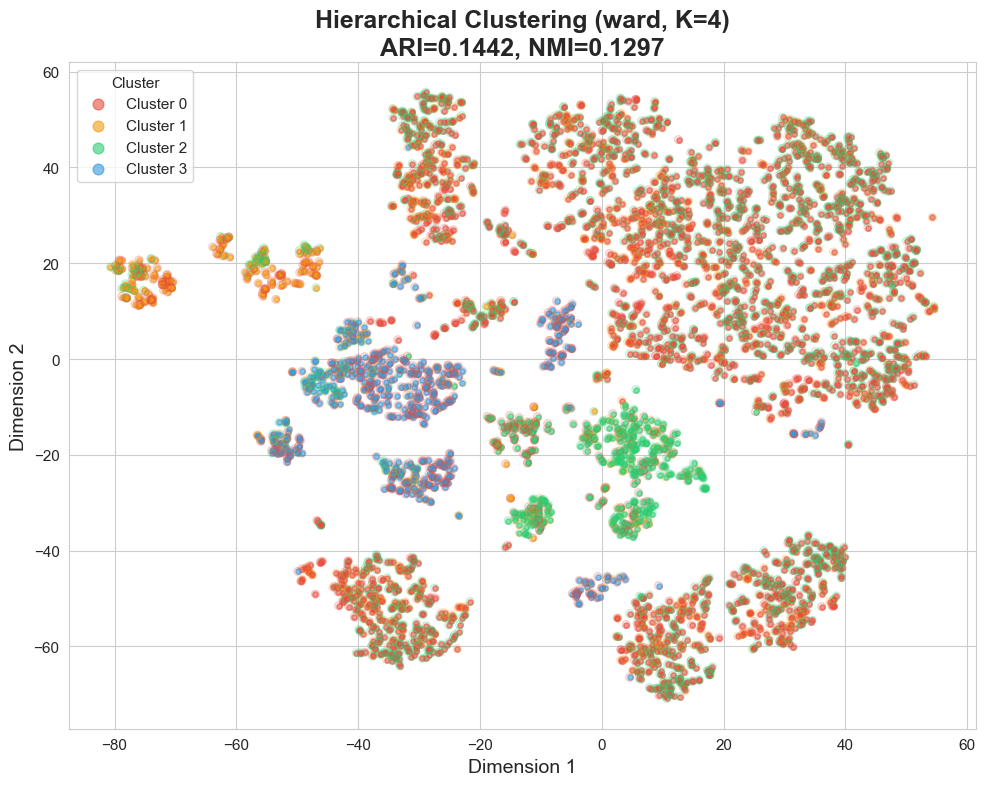

Hierarchical Cluster Size Distribution:
 Cluster  Count  Percentage
       0   3115        70.4
       1    232         5.2
       2    424         9.6
       3    653        14.8
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_dendrogram_ward.png


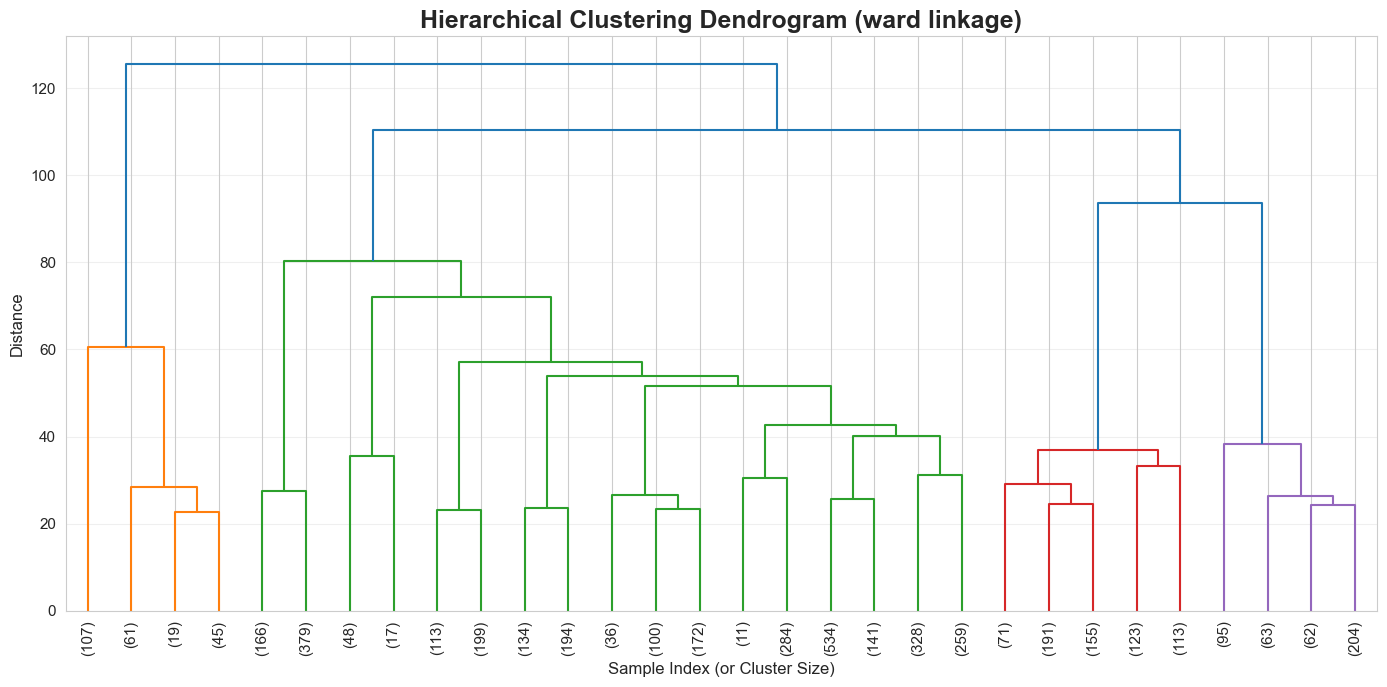


Hierarchical Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           567  655  1893
1           164    3    65
2           181   66   177
3           509   70    74

Dominant Class per Cluster:
  Cluster 0: Graduate (60.8%)
  Cluster 1: Dropout (70.7%)
  Cluster 2: Dropout (42.7%)
  Cluster 3: Dropout (77.9%)


In [9]:
# Hierarchical Clustering with best K (3 and 4 have similar result, use 3 to be consistent with other algorithms) and linkage
best_hier_k = 4
agg_labels = hierarchical_results[best_hier_k]["labels"]
agg_metrics = hierarchical_results[best_hier_k]["metrics"]

print(f"Hierarchical Clustering ({best_linkage}, K={best_hier_k}) Metrics:")
for name, value in agg_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot clusters on tsne
save_path = os.path.join(project_root, "data", "plots", "03a_hierarchical_clusters_tsne.png")
ax = plot_cluster_scatter(tsne_embedding, agg_labels, title=f"Hierarchical Clustering ({best_linkage}, K={best_hier_k})\nARI={agg_metrics['adjusted_rand_index']:.4f}, NMI={agg_metrics['normalized_mutual_info']:.4f}", y_true=y.values, save_path=save_path)
plt.show()

# Hierarchical cluster size distribution table
agg_cluster_sizes = pd.Series(agg_labels).value_counts().sort_index()
agg_size_df = pd.DataFrame({
    "Cluster": agg_cluster_sizes.index,
    "Count": agg_cluster_sizes.values,
    "Percentage": (agg_cluster_sizes.values / len(y) * 100).round(1)
})
print("Hierarchical Cluster Size Distribution:")
print(agg_size_df.to_string(index=False))

# Hierarchical Clustering Dendrogram (best linkage)

from src.clustering import plot_dendrogram
fig = plot_dendrogram(
    X.values,
    method=best_linkage,
    save_path=os.path.join(project_root, "data", "plots", "03a_dendrogram_ward.png"),
)
plt.show()

# Hierarchical cross-tabulation
agg_crosstab = compare_clusters_to_classes(agg_labels, y.values)
print("\nHierarchical Clusters vs True Classes:")
print(agg_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in agg_crosstab.index:
    row = agg_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

## 4.1 GMM K-Value and Covariance Exploration

We explore different K values (K=3,4,5,6) and covariance types (full, tied, diag, spherical) for GMM to find the optimal configuration.

In [10]:
# GMM K-Value and Covariance Exploration
from sklearn.mixture import GaussianMixture

print("GMM K-Value and Covariance Exploration:")
print(f"{'K':>3} | {'Cov':>10} | {'ARI':>8} | {'NMI':>8} | {'Silhouette':>10} | {'CH Index':>10} | {'DB Index':>10}")
print("-" * 75)

gmm_results = {}
best_gmm_config = 1
best_gmm_ari = 0

for k in [3, 4, 5, 6]:
    for cov in ['full', 'tied', 'diag', 'spherical']:
        gmm = GaussianMixture(n_components=k, covariance_type=cov, random_state=42, n_init=5)
        labels = gmm.fit_predict(X.values)
        metrics = evaluate_clustering(X.values, labels, y.values)
        gmm_results[(k, cov)] = {"labels": labels, "metrics": metrics}
        ari = metrics.get('adjusted_rand_index', 0)
        nmi = metrics.get('normalized_mutual_info', 0)
        sil = metrics.get('silhouette', 0)
        ch = metrics.get('calinski_harabasz', 0)
        db = metrics.get('davies_bouldin', 0)
        print(f"{k:>3} | {cov:>10} | {ari:>8.4f} | {nmi:>8.4f} | {sil:>10.4f} | {ch:>10.2f} | {db:>10.4f}")
        
        if ari > best_gmm_ari:
            best_gmm_ari = ari
            best_gmm_config = (k, cov)

print(f"\nBest GMM Configuration: K={best_gmm_config[0]}, covariance={best_gmm_config[1]} (ARI={best_gmm_ari:.4f})")

best_gmm_k = best_gmm_config[0]
best_gmm_cov = best_gmm_config[1]
best_gmm_labels = gmm_results[best_gmm_config]["labels"]
best_gmm_metrics = gmm_results[best_gmm_config]["metrics"]

GMM K-Value and Covariance Exploration:
  K |        Cov |      ARI |      NMI | Silhouette |   CH Index |   DB Index
---------------------------------------------------------------------------
  3 |       full |   0.2222 |   0.1670 |     0.1171 |     397.58 |     2.5303
  3 |       tied |   0.1204 |   0.1159 |     0.2256 |     474.38 |     1.8799
  3 |       diag |   0.2064 |   0.1594 |     0.1559 |     455.21 |     2.5179
  3 |  spherical |   0.1047 |   0.0870 |     0.0748 |     389.16 |     2.4858
  4 |       full |   0.2027 |   0.1603 |     0.1550 |     328.27 |     3.0155
  4 |       tied |   0.0880 |   0.0832 |     0.1286 |     447.61 |     1.9457
  4 |       diag |   0.2063 |   0.1665 |     0.1774 |     447.69 |     2.4895
  4 |  spherical |   0.0884 |   0.1106 |     0.0690 |     463.90 |     2.4583
  5 |       full |   0.2042 |   0.1535 |     0.1846 |     423.74 |     2.1232
  5 |       tied |   0.1507 |   0.1365 |     0.2254 |     488.28 |     1.6485
  5 |       diag |   0.183

GMM (K=4, covariance=diag) Metrics:
  silhouette: 0.1559
  silhouette_std: 0.1580
  calinski_harabasz: 455.2057
  davies_bouldin: 2.5179
  noise_ratio: 0.0000
  adjusted_rand_index: 0.2064
  normalized_mutual_info: 0.1594
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_gmm_clusters_tsne.png


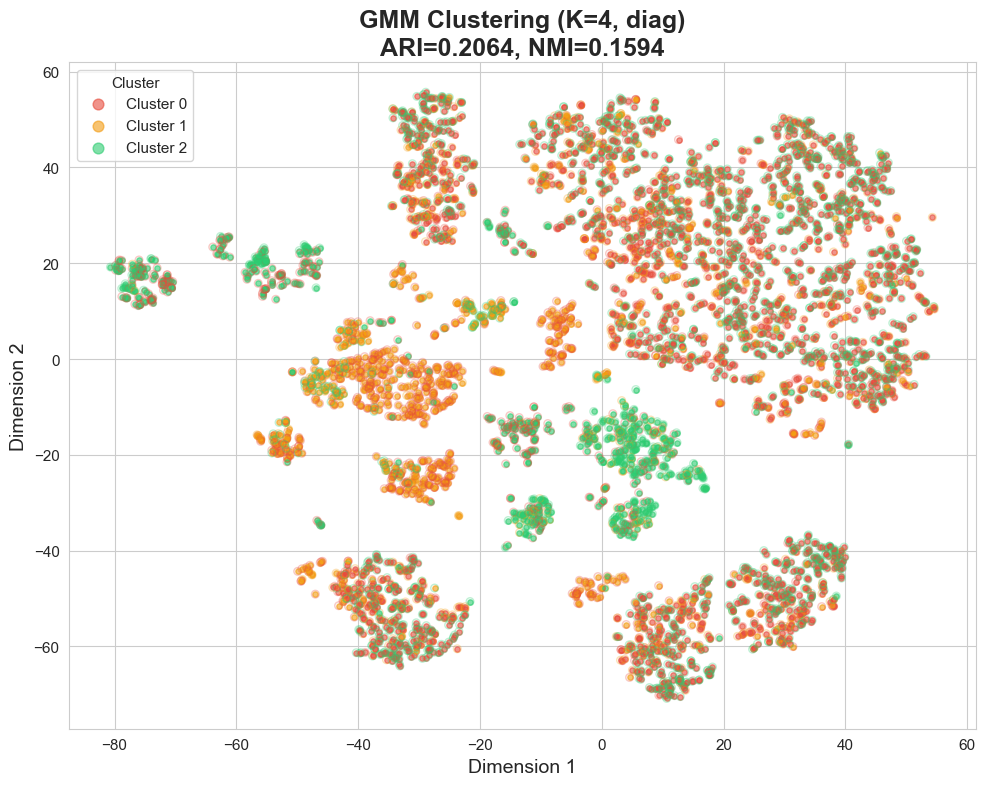


Cluster probabilities (first 5 points):
[[1. 0. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]
 [0. 1. 0. 0.]]

GMM Clusters vs True Classes:
True Class    0    1     2
Cluster                   
0           371  596  1824
1           666  122   130
2           384   76   255

Dominant Class per Cluster:
  Cluster 0: Graduate (65.4%)
  Cluster 1: Dropout (72.5%)
  Cluster 2: Dropout (53.7%)


In [11]:
# GMM with best configuration (K=3, full covariance)
gmm_labels = gmm_results[(3, 'diag')]["labels"]
gmm_metrics = gmm_results[(3, 'diag')]["metrics"]
gmm_k = 4
best_gmm_cov = 'diag'

print(f"GMM (K={gmm_k}, covariance={best_gmm_cov}) Metrics:")
for name, value in gmm_metrics.items():
    print(f"  {name}: {value:.4f}" if isinstance(value, float) else f"  {name}: {value}")

# Plot GMM clusters on tsne
save_path = os.path.join(project_root, "data", "plots", "03a_gmm_clusters_tsne.png")
ax = plot_cluster_scatter(
    tsne_embedding, gmm_labels,
    title=f"GMM Clustering (K={gmm_k}, {best_gmm_cov})\nARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}",
    y_true=y.values, save_path=save_path
)
plt.show()

# Cluster probabilities (sample of first 5 points)
from sklearn.mixture import GaussianMixture
gmm_model = GaussianMixture(n_components=gmm_k, covariance_type=best_gmm_cov, random_state=42, n_init=5)
gmm_model.fit(X.values)
gmm_probs = gmm_model.predict_proba(X.values)
print(f"\nCluster probabilities (first 5 points):")
print(gmm_probs[:5].round(3))

# GMM cross-tabulation
gmm_crosstab = compare_clusters_to_classes(gmm_labels, y.values)
print("\nGMM Clusters vs True Classes:")
print(gmm_crosstab.to_string())

print("\nDominant Class per Cluster:")
for cluster in gmm_crosstab.index:
    row = gmm_crosstab.loc[cluster]
    dominant_class = row.idxmax()
    dominant_pct = row.max() / row.sum() * 100
    print(f"  Cluster {cluster}: {class_names[dominant_class]} ({dominant_pct:.1f}%)")

## 5. Multi-Algorithm Comparison

We compare all three algorithms (K-Means, Hierarchical, GMM) using six evaluation metrics: Silhouette Score, Calinski-Harabasz Index, Davies-Bouldin Index, Adjusted Rand Index (ARI), and Normalized Mutual Information (NMI). Silhouette, CH, and DB are unsupervised metrics that do not require ground truth labels, while ARI and NMI measure alignment with the true class assignments.

CLUSTERING ALGORITHM COMPARISON:
------------------------------------------------------------------------------------------
                     Algorithm |    K | Silhouette |     CH Index |   DB Index |      ARI |      NMI
------------------------------------------------------------------------------------------
                 K-Means (K=4) |    4 |     0.2282 |       592.06 |     1.6740 |   0.1572 |   0.1379
      Hierarchical (Ward, K=4) |    4 |     0.2098 |       558.90 |     1.6948 |   0.1442 |   0.1297
               GMM (K=3, diag) |    3 |     0.1559 |       455.21 |     2.5179 |   0.2064 |   0.1594
------------------------------------------------------------------------------------------
Plot saved to /media/appleblue17/E/vscode/Assignments/2026Spring/ML/2026.04.27 Final Project/dsaa2011_machine_learning/data/plots/03a_algorithm_comparison.png


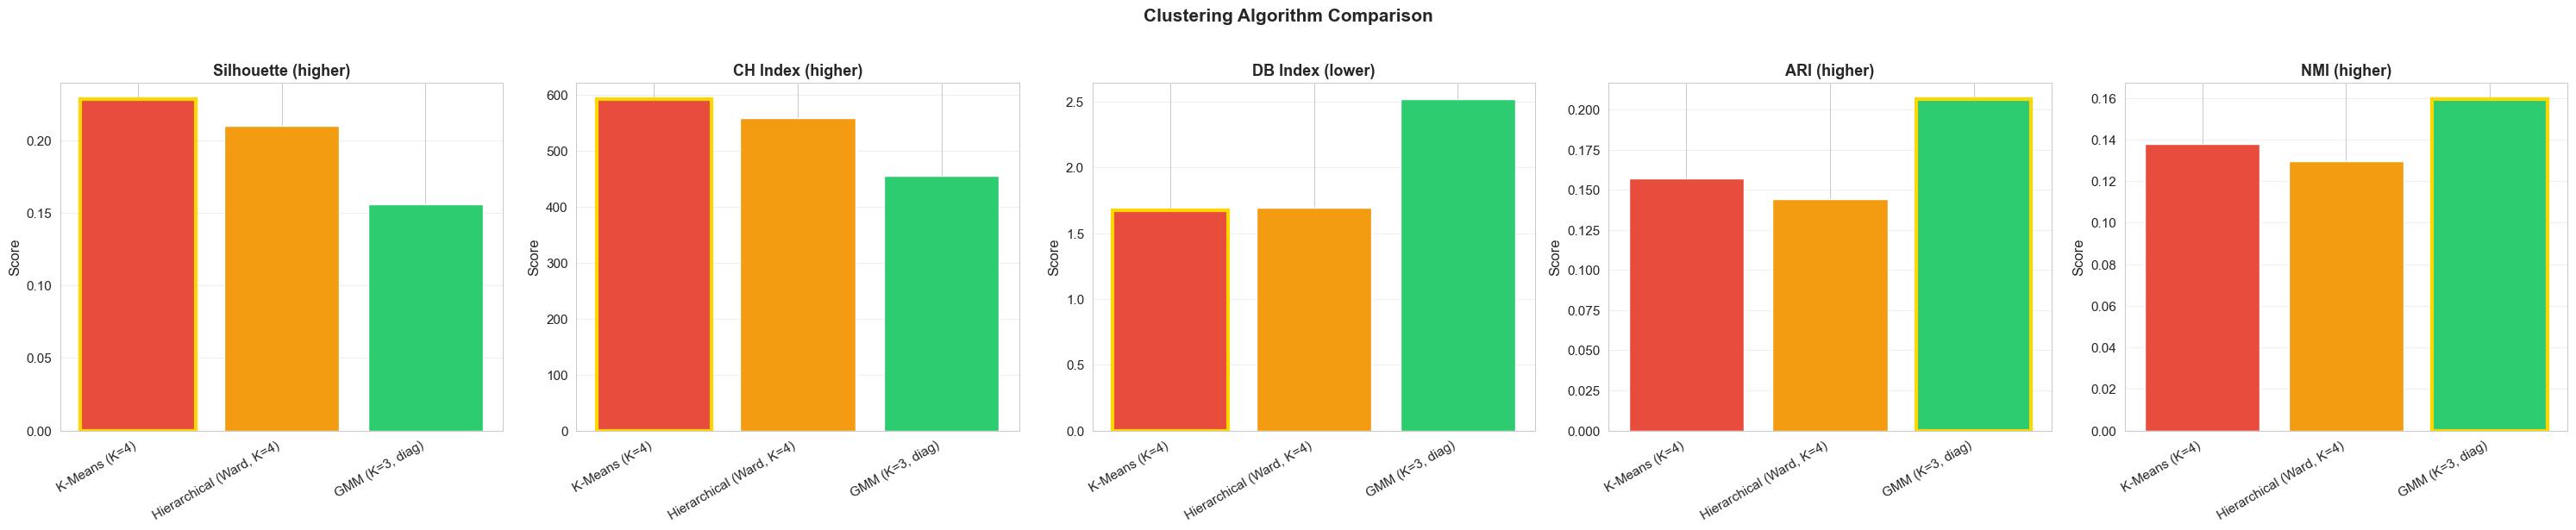

In [12]:
# Multi-algorithm comparison (using best configurations for each algorithm)
all_algorithms = {
    f"K-Means (K={optimal_k})": {"labels": kmeans_labels, "metrics": kmeans_metrics, "n_clusters": optimal_k},
    f"Hierarchical (Ward, K={best_hier_k})": {"labels": agg_labels, "metrics": agg_metrics, "n_clusters": best_hier_k},
    f"GMM (K={best_gmm_k}, {best_gmm_cov})": {"labels": gmm_labels, "metrics": gmm_metrics, "n_clusters": best_gmm_k},
}

print("CLUSTERING ALGORITHM COMPARISON:")
print("-" * 90)
print(f"{'Algorithm':>30} | {'K':>4} | {'Silhouette':>10} | {'CH Index':>12} | {'DB Index':>10} | {'ARI':>8} | {'NMI':>8}")
print("-" * 90)

for alg_name, results in all_algorithms.items():
    m = results["metrics"]
    k = results["n_clusters"]
    print(f"{alg_name:>30} | {k:>4} | {m.get('silhouette', 0):>10.4f} | {m.get('calinski_harabasz', 0):>12.2f} | {m.get('davies_bouldin', 0):>10.4f} | {m.get('adjusted_rand_index', 0):>8.4f} | {m.get('normalized_mutual_info', 0):>8.4f}")

print("-" * 90)

all_results_dict = {alg: res["metrics"] for alg, res in all_algorithms.items()}

save_path = os.path.join(project_root, "data", "plots", "03a_algorithm_comparison.png")
fig = plot_algorithm_comparison(all_results_dict, y.values, save_path=save_path)
plt.show()

## 6. Best Algorithm Analysis

In [13]:
# Best algorithm determination based on ARI and NMI
# Compare best configurations: K-Means K=4, Hierarchical K=3, GMM K=4 (tied)

print("Best algorithm comparison (ARI/NMI):")
print(f"  K-Means (K=3):                    ARI={kmeans_metrics['adjusted_rand_index']:.4f}, NMI={kmeans_metrics['normalized_mutual_info']:.4f}")
print(f"  Hierarchical (K=3):                ARI={agg_metrics['adjusted_rand_index']:.4f}, NMI={agg_metrics['normalized_mutual_info']:.4f}")
print(f"  GMM (K=3, full covariance):       ARI={gmm_metrics['adjusted_rand_index']:.4f}, NMI={gmm_metrics['normalized_mutual_info']:.4f}")

# Find best
all_aris = {
    f"K-Means (K={optimal_k})": kmeans_metrics['adjusted_rand_index'],
    f"Hierarchical (K={best_hier_k})": agg_metrics['adjusted_rand_index'],
    f"GMM (K={best_gmm_k}, {best_gmm_cov})": gmm_metrics['adjusted_rand_index'],
}
best_algorithm = max(all_aris, key=all_aris.get)
print(f"\nBest algorithm: {best_algorithm} (ARI={all_aris[best_algorithm]:.4f})")

# Get best labels
if "K-Means" in best_algorithm:
    best_labels = kmeans_labels
elif "Hierarchical" in best_algorithm:
    best_labels = agg_labels
else:
    best_labels = gmm_labels

Best algorithm comparison (ARI/NMI):
  K-Means (K=3):                    ARI=0.1572, NMI=0.1379
  Hierarchical (K=3):                ARI=0.1442, NMI=0.1297
  GMM (K=3, full covariance):       ARI=0.2064, NMI=0.1594

Best algorithm: GMM (K=3, diag) (ARI=0.2064)


In [14]:
# Cross-tabulation for best algorithm
crosstab = compare_clusters_to_classes(best_labels, y.values)

# Get the best metrics
best_metrics_map = {
    f"K-Means (K={optimal_k})": kmeans_metrics,
    f"Hierarchical (K={best_hier_k})": agg_metrics,
    f"GMM (K={best_gmm_k}, {best_gmm_cov})": best_gmm_metrics,
}
best_metrics = best_metrics_map[best_algorithm]

print(f"Cross-tabulation: {best_algorithm} Clusters vs True Classes")
print(crosstab.to_string())

print(f"CONCLUSION: {best_algorithm} is the best clustering algorithm")
print(f"            with ARI={best_metrics['adjusted_rand_index']:.4f} and NMI={best_metrics['normalized_mutual_info']:.4f}")

Cross-tabulation: GMM (K=3, diag) Clusters vs True Classes
True Class    0    1     2
Cluster                   
0           371  596  1824
1           666  122   130
2           384   76   255
CONCLUSION: GMM (K=3, diag) is the best clustering algorithm
            with ARI=0.2222 and NMI=0.1670
